In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("student_lifestyle_dataset.csv")

In [ ]:
df.info()

df.describe()

df["Stress_Level"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


,count
Stress_Level,
High,1029
Moderate,674
Low,297


<Axes: xlabel='Stress_Level', ylabel='count'>

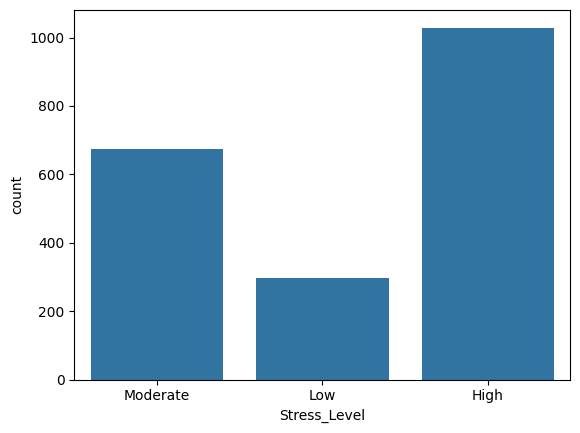

In [ ]:
import seaborn as sns

sns.countplot(
    data=df,
    x="Stress_Level"
)

In [ ]:
df.drop(
    "Student_ID",
    axis=1,
    inplace=True
)

In [ ]:
le = LabelEncoder()

df["Stress_Level"] = le.fit_transform(
    df["Stress_Level"]
)

In [ ]:
X = df.drop(
    "Stress_Level",
    axis=1
)

y = df["Stress_Level"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

Random Forest Accuracy: 1.0000
XGBoost Accuracy: 1.0000


In [ ]:
from sklearn.metrics import accuracy_score

# Random Forest
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# XGBoost
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy :", rf_acc)
print("XGBoost Accuracy :", xgb_acc)

Random Forest Accuracy : 1.0
XGBoost Accuracy : 1.0


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc]
})

print(comparison)

           Model  Accuracy
0  Random Forest       1.0
1        XGBoost       1.0
